«Анализ базы данных DVD Rental: SQL + Python



Цель
Проанализировать выручку, клиентов, категории и фильмы на основе данных PostgreSQL.

In [ ]:
from google.colab import files

In [ ]:
import pandas as pd

In [ ]:
revenue_month = pd.read_csv('revenue_by_month.csv')


In [ ]:
revenue_month['date'] = pd.to_datetime(revenue_month['date'])

In [ ]:
revenue_month['date']  = revenue_month['date'].dt.to_period('M')

In [ ]:
revenue_month.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype    
---  ------      --------------  -----    
 0   date        4 non-null      period[M]
 1   sum_amount  4 non-null      float64  
dtypes: float64(1), period[M](1)
memory usage: 196.0 bytes


In [ ]:
import matplotlib.pyplot as plt

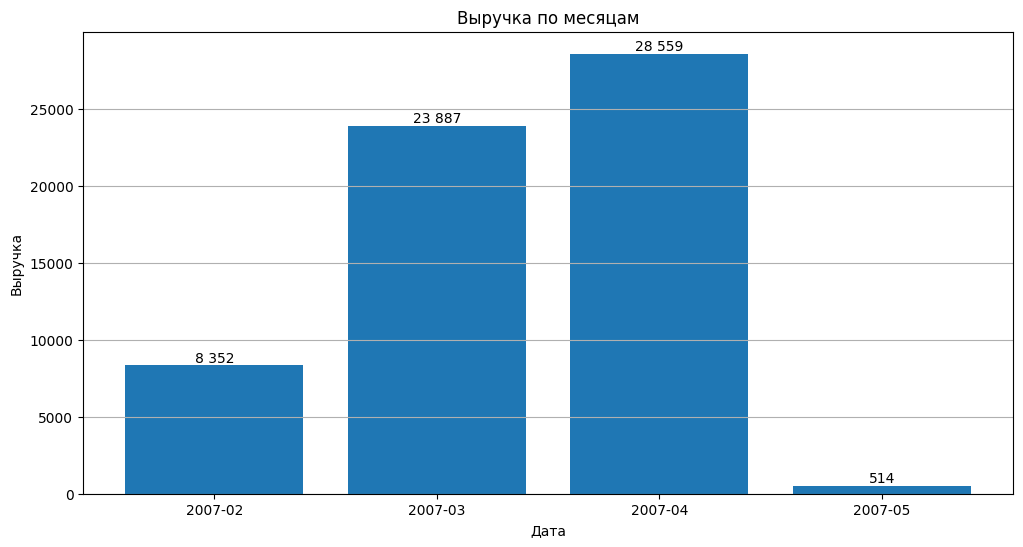

In [ ]:
plt.figure(figsize=(12, 6))
bars = plt.bar(
    revenue_month['date'].astype(str),
    revenue_month['sum_amount'])
plt.title('Выручка по месяцам')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.grid(axis='y')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}'.replace(',', ' '),
        ha='center',
        va='bottom'  )
plt.show()




Данные охватывают период с 14 февраля по 14 мая 2007 года. Среди полных месяцев выручка выросла с 23,9 тыс. в марте до 28,6 тыс. в апреле. Февраль и май представлены не полностью, поэтому их значения — 8,4 тыс. и 514 соответственно — нельзя напрямую сравнивать с полными месяцами.

In [ ]:
revenue_store = pd.read_csv('выручка по магазинам.csv')

In [ ]:
revenue_store.head()

,store_id,total_amount
0,1,30252.12
1,2,31059.92


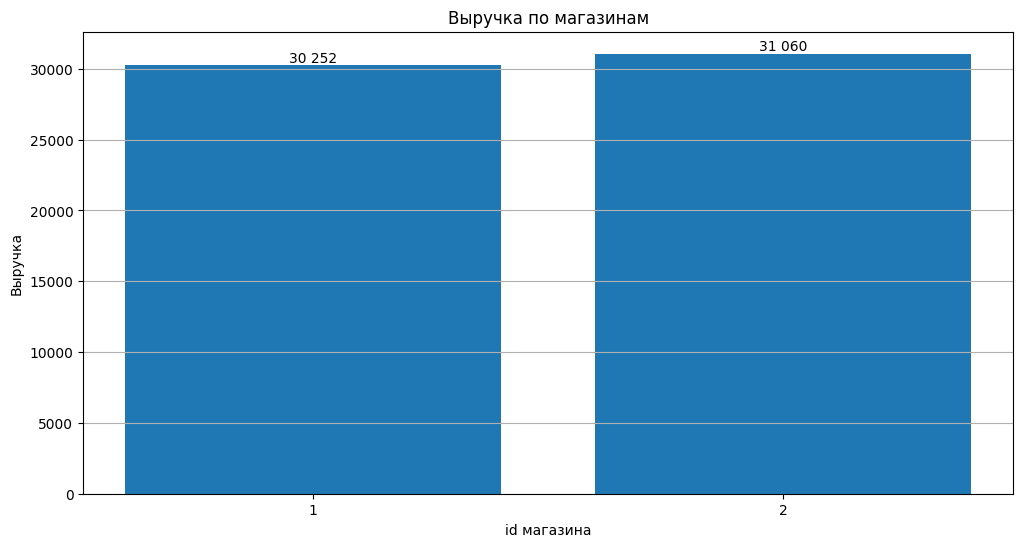

In [ ]:
plt.figure(figsize=(12, 6))
bars = plt.bar(
    revenue_store['store_id'].astype(str),
    revenue_store['total_amount'])
plt.title('Выручка по магазинам')
plt.xlabel('id магазина')
plt.ylabel('Выручка')
plt.grid(axis='y')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}'.replace(',', ' '),
        ha='center',
        va='bottom'  )
plt.show()

Выручка двух магазинов находится примерно на одном уровне. Магазин №2 показал немного более высокий результат — 31,1 тыс. против 30,3 тыс. у магазина №1. Разница составляет около 808, поэтому существенного разрыва между магазинами нет.

In [ ]:
customers_store = pd.read_csv('количество клиентов по магазинам.csv')

In [ ]:
customers_store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   store_id  2 non-null      int64
 1   count     2 non-null      int64
dtypes: int64(2)
memory usage: 164.0 bytes


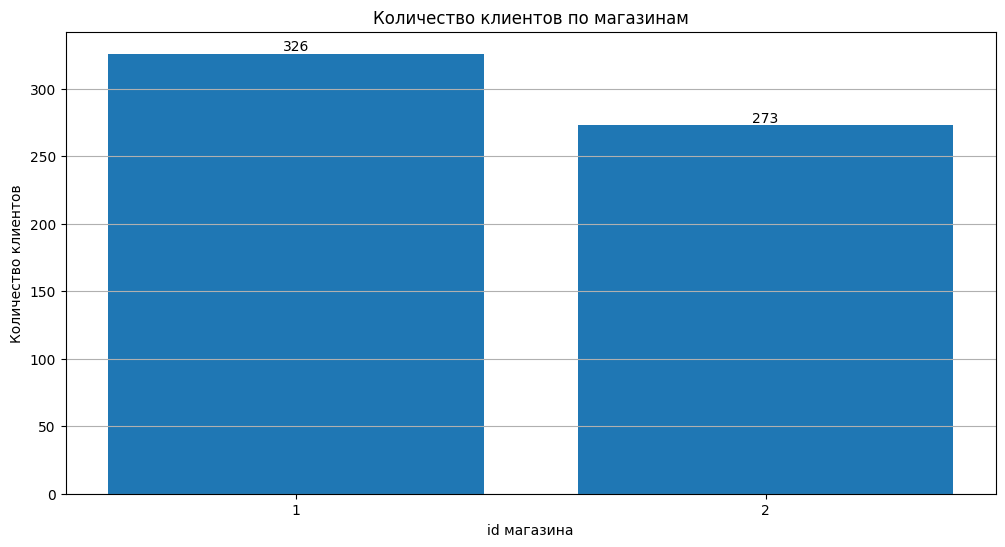

In [ ]:
plt.figure(figsize=(12, 6))
bars = plt.bar(
    customers_store['store_id'].astype(str),
    customers_store['count'])
plt.title('Количество клиентов по магазинам')
plt.xlabel('id магазина')
plt.ylabel('Количество клиентов')
plt.grid(axis='y')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}'.replace(',', ' '),
        ha='center',
        va='bottom'  )
plt.show()

В магазине №1 обслуживается больше клиентов: 326 против 273 в магазине №2. При этом общая выручка магазина №2 немного выше. Это может указывать на более высокий средний доход на одного клиента во втором магазине.

In [ ]:
store_metrics = revenue_store.merge(customers_store, on = 'store_id')

In [ ]:
store_metrics['Выручка_на_клиента'] = store_metrics['total_amount'] / store_metrics['count']

In [ ]:
store_metrics['Выручка_на_клиента'] = store_metrics['Выручка_на_клиента'].round(2)

In [ ]:
store_metrics

,store_id,total_amount,count,Выручка_на_клиента
0,1,30252.12,326,92.80
1,2,31059.92,273,113.77


Магазин №2 показывает более высокую выручку на одного клиента — 113,77 против 92,80 у магазина №1. Это объясняет, почему при меньшем количестве клиентов его общая выручка немного выше.

In [ ]:
popular_categories = pd.read_csv('популярные категории.csv')

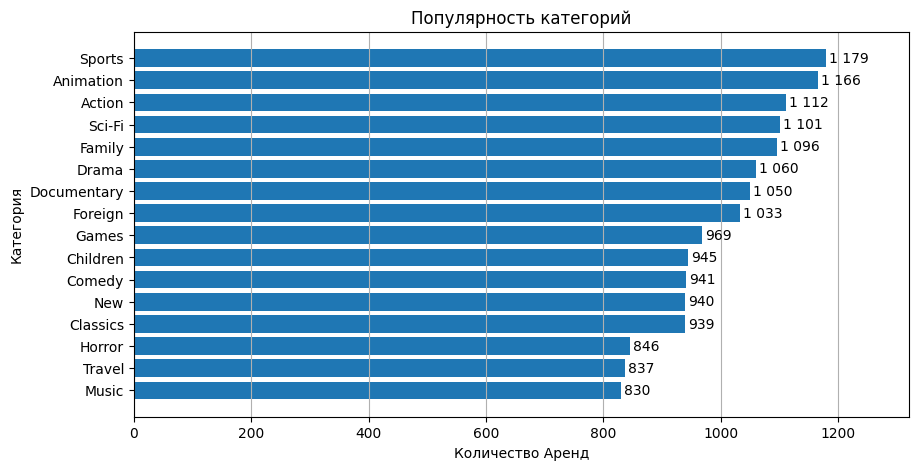

In [ ]:
plt.figure(figsize=(10, 5))
bars = plt.barh(
    popular_categories['name'],
    popular_categories['cnt_rental'])
plt.title('Популярность категорий')
plt.xlabel('Количество Аренд')
plt.ylabel('Категория')
# подписи значений
plt.gca().invert_yaxis()
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 5,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}'.replace(',', ' '),
        va='center'
    )
plt.grid(axis='x')
plt.xlim(0, popular_categories['cnt_rental'].max() * 1.12)
plt.show()


Наиболее популярной категорией является Sports — 1 179 аренд. Далее идут Animation — 1 166 и Action — 1 112. Наименьшее количество аренд среди представленных категорий у Music — около 830. При этом разрыв между категориями относительно небольшой, поэтому спрос распределён достаточно равномерно.

In [ ]:
top_revenue_films = pd.read_csv('самые доходные фильмы.csv')

In [ ]:
top_revenue_films_10 = top_revenue_films.head(10)

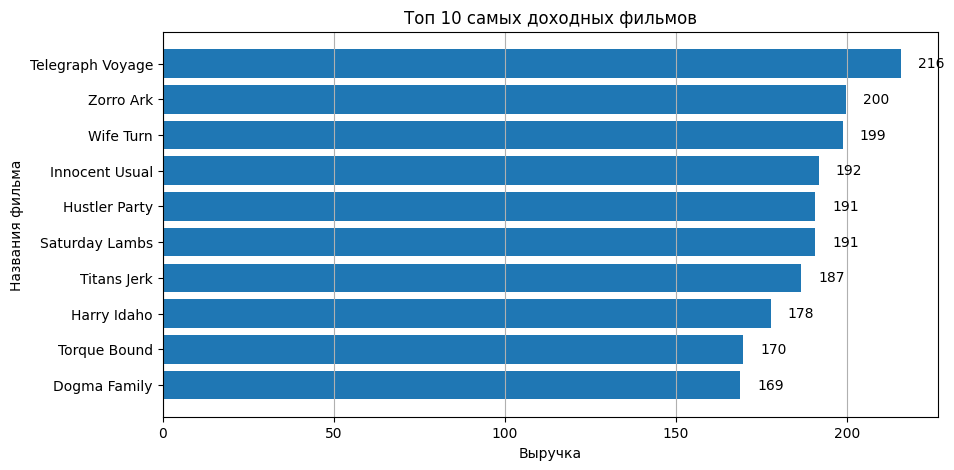

In [ ]:
plt.figure(figsize=(10, 5))
bars = plt.barh(
    top_revenue_films_10['title'],
    top_revenue_films_10['sum_amount'])
plt.title('Топ-10 самых доходных фильмов')
plt.xlabel('Выручка')
plt.ylabel('Названия фильма')
# подписи значений
plt.gca().invert_yaxis()
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 5,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}'.replace(',', ' '),
        va='center'
    )
plt.grid(axis='x')

plt.show()

Наибольшую выручку принёс фильм Telegraph Voyage — 216. Далее идут Zorro Ark — 200 и Wife Turn — 199. Разрыв между фильмами в топ-10 относительно небольшой: значения находятся в диапазоне от 169 до 216.

In [ ]:
average_payment = pd.read_csv('средний платеж.csv')

In [ ]:
average_payment

,avg_amount
0,4.200606


Средний размер одного платежа составляет 4,20.

In [ ]:
top_customers = pd.read_csv('клиенты с наибольшей суммой платежа.csv')

Наибольшую общую сумму платежей среди клиентов внесла Eleanor, клиент №148 — 211,55.

In [ ]:
rarely_rented_films = pd.read_csv('фильмы которые редко арендуют.csv')

In [ ]:
rarely_rented_films.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   film_id    958 non-null    int64 
 1   title      958 non-null    object
 2   count_cnt  958 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 22.6+ KB


In [ ]:
top_10_rarely_rented_films = rarely_rented_films.head(10)

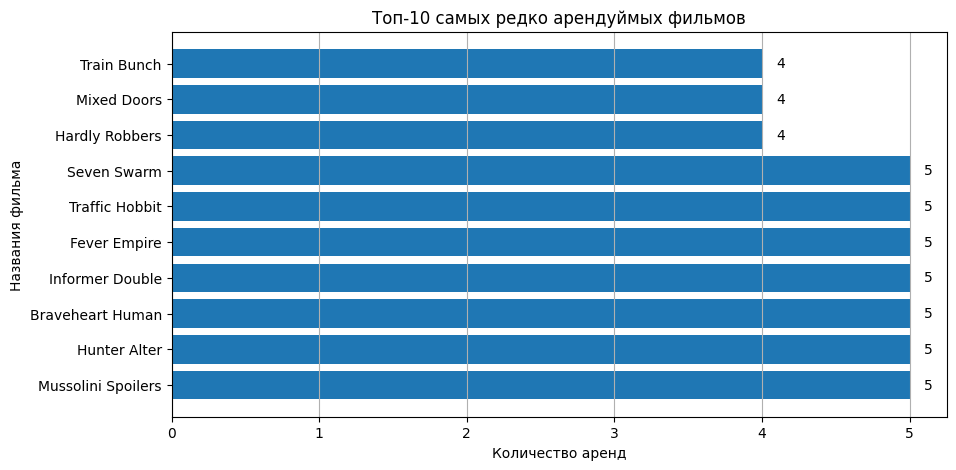

In [ ]:
plt.figure(figsize=(10, 5))
bars = plt.barh(
    top_10_rarely_rented_films['title'],
    top_10_rarely_rented_films['count_cnt'])
plt.title('Топ-10 самых редко арендуймых фильмов')
plt.xlabel('Количество аренд')
plt.ylabel('Названия фильма')
# подписи значений
plt.gca().invert_yaxis()
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}'.replace(',', ' '),
        va='center'
    )
plt.grid(axis='x')

plt.show()

Реже всего арендовали фильмы Train Bunch, Mixed Doors и Hardly Robbers — по 4 раза. Остальные фильмы из десятки наименее востребованных арендовали по 5 раз. Разница внутри этой группы минимальна.

In [ ]:
never_rented_films = pd.read_csv('фильмы которые не арендуют.csv')

In [ ]:
never_rented_films.head(10)

,film_id,title
0,1,Academy Dinosaur
1,802,Sky Miracle
2,497,Kill Brotherhood
3,801,Sister Freddy
4,359,Gladiator Westward
5,325,Floats Garden
6,33,Apollo Teen
7,198,Crystal Breaking
8,419,Hocus Frida
9,332,Frankenstein Stranger


В базе выявлено 43 фильма, которые ни разу не были арендованы. Это может указывать на низкий спрос, недостаточную представленность этих фильмов или проблемы с доступностью отдельных копий. Такие позиции стоит дополнительно проверить перед решениями об ассортименте.

Итоги анализа

Данные охватывают период с 14 февраля по 14 мая 2007 года. Поскольку февраль и май представлены не полностью, корректнее сравнивать между собой полные месяцы — март и апрель. Выручка выросла с 23,9 тыс. в марте до 28,6 тыс. в апреле.

Выручка двух магазинов находится примерно на одном уровне. Магазин №2 получил 31,1 тыс., а магазин №1 — 30,3 тыс. При этом у магазина №1 больше клиентов: 326 против 273. Выручка на одного клиента выше у магазина №2 — 113,77 против 92,80, что объясняет его более высокий общий результат при меньшем количестве клиентов.

Наиболее популярными категориями стали Sports, Animation и Action. Самым доходным фильмом оказался Telegraph Voyage с выручкой 216. Средний размер одного платежа составил 4,20. Наибольшую общую сумму платежей внесла Eleanor, клиент №148, — 211,55.

Также были выявлены фильмы с низким спросом. Реже всего арендовали Train Bunch, Mixed Doors и Hardly Robbers — по 4 раза. Кроме того, 43 фильма ни разу не были арендованы. Такие позиции стоит дополнительно проверить: возможными причинами могут быть низкий спрос, недостаточная доступность копий или особенности ассортимента.

В целом анализ показал, что магазины имеют сопоставимую выручку, однако отличаются по количеству клиентов и выручке на одного клиента. Для дальнейшего анализа полезно подробнее изучить причины более высокой эффективности магазина №2 и проверить фильмы без аренд.